# Parametric Curve Parameter Recovery — θ, M, X

**Approach**: treat this as point-cloud-to-curve fitting. For a candidate (θ, M, X), generate a
dense reference curve, measure nearest-neighbor distance from every data point to that curve,
and minimize this loss with a bounded global optimizer (differential evolution), then polish
locally (Nelder-Mead).



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.optimize import differential_evolution, minimize

np.random.seed(42)


## Step 1 — Load and Inspect Data

(1500, 2)
            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340


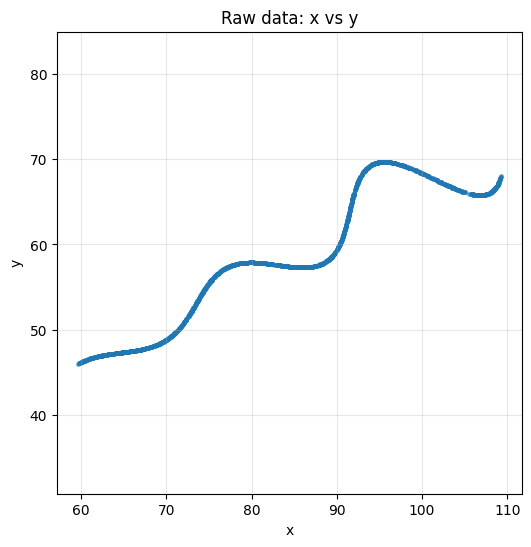

In [2]:
df = pd.read_csv("xy_data.csv")
print(df.shape)
print(df.head())
assert df.isnull().sum().sum() == 0, "Missing values found in dataset"

x_data = df["x"].to_numpy()
y_data = df["y"].to_numpy()

plt.figure(figsize=(6, 6))
plt.scatter(x_data, y_data, s=6, alpha=0.6)
plt.title("Raw data: x vs y")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()


## Step 2 — Forward Model

In [3]:
def curve_xy(t, theta, M, X):
    """theta in radians. Returns (x, y) arrays for parameter t array."""
    v = np.exp(M * np.abs(t)) * np.sin(0.3 * t)
    x = t * np.cos(theta) - v * np.sin(theta) + X
    y = 42 + t * np.sin(theta) + v * np.cos(theta)
    return x, y


## Step 3 — Dense Reference Curve Sampling

In [4]:
T_MIN, T_MAX = 6.0, 60.0
N_DENSE = 8000  # dense enough to resolve the sin(0.3t) oscillation without aliasing

t_dense = np.linspace(T_MIN, T_MAX, N_DENSE)


## Step 4 — Fit-Quality Metric (point-cloud to curve distance)

In [5]:
def loss(params, x_data, y_data, t_dense):
    theta, M, X = params
    x_model, y_model = curve_xy(t_dense, theta, M, X)
    tree = cKDTree(np.column_stack([x_model, y_model]))
    dists, _ = tree.query(np.column_stack([x_data, y_data]))
    return np.mean(dists)


## Step 5 — Search Bounds

In [6]:
bounds = [
    (0.0, np.deg2rad(50.0)),  # theta (radians)
    (-0.05, 0.05),            # M
    (0.0, 100.0),             # X
]


## Step 6 — Global Optimization (Differential Evolution)

In [7]:
import time

# Two-phase search: coarse global DE then full-resolution polish.
# Subsampled data + coarser curve keep DE fast; polish restores accuracy on all 1500 points.
_sub_rng = np.random.default_rng(42)
_sub_idx = _sub_rng.choice(len(x_data), size=800, replace=False)
_x_sub, _y_sub = x_data[_sub_idx], y_data[_sub_idx]
_t_coarse = np.linspace(T_MIN, T_MAX, 4000)

_t0 = time.perf_counter()
result = differential_evolution(
    loss,
    bounds=bounds,
    args=(_x_sub, _y_sub, _t_coarse),
    strategy="best1bin",
    maxiter=200,
    popsize=15,
    tol=1e-6,
    mutation=(0.5, 1.5),
    recombination=0.7,
    polish=False,
    seed=42,
    updating="immediate",
    workers=1,
)
_de_elapsed = time.perf_counter() - _t0

_polish = minimize(
    loss,
    x0=result.x,
    args=(x_data, y_data, t_dense),
    method="Nelder-Mead",
    options={"xatol": 1e-10, "fatol": 1e-12, "maxiter": 5000, "maxfev": 5000},
)
result.x = _polish.x
result.fun = _polish.fun
_total_elapsed = time.perf_counter() - _t0

theta_de, M_de, X_de = result.x
print("DE result (coarse search + full-resolution polish):")
print(f"  theta = {theta_de:.6f} rad ({np.rad2deg(theta_de):.4f} deg)")
print(f"  M     = {M_de:.6f}")
print(f"  X     = {X_de:.6f}")
print(f"  loss  = {result.fun:.6f}")
print(f"  time  = {_de_elapsed:.1f}s DE + {_total_elapsed - _de_elapsed:.1f}s polish = {_total_elapsed:.1f}s total")


DE result (coarse search + full-resolution polish):
  theta = 0.523599 rad (30.0000 deg)
  M     = 0.030000
  X     = 55.000071
  loss  = 0.002053
  time  = 8.9s DE + 0.7s polish = 9.7s total


## Step 7 — Local Refinement (Nelder-Mead)

In [8]:
refined = minimize(
    loss,
    x0=result.x,
    args=(x_data, y_data, t_dense),
    method="Nelder-Mead",
    options={"xatol": 1e-10, "fatol": 1e-12, "maxiter": 20000, "maxfev": 20000},
)

theta_final, M_final, X_final = refined.x
print("Refined result:")
print(f"  theta = {theta_final:.6f} rad ({np.rad2deg(theta_final):.4f} deg)")
print(f"  M     = {M_final:.6f}")
print(f"  X     = {X_final:.6f}")
print(f"  loss  = {refined.fun:.6f}")


Refined result:
  theta = 0.523599 rad (30.0000 deg)
  M     = 0.030000
  X     = 55.000071
  loss  = 0.002053


## Step 8 — Convergence Stability Check

Re-run the global search with different seeds and confirm agreement.

In [9]:
import time

# Same fast two-phase search as Step 6: coarse DE on subsample, full-resolution polish.
_stability_seeds = [1, 7, 21, 99]
_sub_rng = np.random.default_rng(42)
_sub_idx = _sub_rng.choice(len(x_data), size=800, replace=False)
_x_sub, _y_sub = x_data[_sub_idx], y_data[_sub_idx]
_t_coarse = np.linspace(T_MIN, T_MAX, 4000)


def _fast_fit(seed):
    r = differential_evolution(
        loss,
        bounds=bounds,
        args=(_x_sub, _y_sub, _t_coarse),
        strategy="best1bin",
        maxiter=200,
        popsize=15,
        tol=1e-6,
        mutation=(0.5, 1.5),
        recombination=0.7,
        polish=False,
        seed=seed,
        updating="immediate",
        workers=1,
    )
    p = minimize(
        loss,
        x0=r.x,
        args=(x_data, y_data, t_dense),
        method="Nelder-Mead",
        options={"xatol": 1e-10, "fatol": 1e-12, "maxiter": 5000, "maxfev": 5000},
    )
    return p.x, p.fun


seed_results = []
_t0 = time.perf_counter()
for seed in _stability_seeds:
    x_opt, fun = _fast_fit(seed)
    seed_results.append((seed, *x_opt, fun))
    print(
        f"seed={seed:>3}  theta={x_opt[0]:.6f}  M={x_opt[1]:.6f}  "
        f"X={x_opt[2]:.6f}  loss={fun:.6f}"
    )

seed_df = pd.DataFrame(seed_results, columns=["seed", "theta", "M", "X", "loss"])

print(
    f"\nStep 7 reference: theta={theta_final:.6f}  M={M_final:.6f}  "
    f"X={X_final:.6f}  loss={refined.fun:.6f}"
)
print(
    "Seed spread:  "
    f"dtheta={seed_df['theta'].max() - seed_df['theta'].min():.2e}  "
    f"dM={seed_df['M'].max() - seed_df['M'].min():.2e}  "
    f"dX={seed_df['X'].max() - seed_df['X'].min():.2e}  "
    f"dloss={seed_df['loss'].max() - seed_df['loss'].min():.2e}"
)
print(f"Total time: {time.perf_counter() - _t0:.1f}s")

seed_df


seed=  1  theta=0.523599  M=0.030000  X=55.000071  loss=0.002053
seed=  7  theta=0.523599  M=0.030000  X=55.000071  loss=0.002053
seed= 21  theta=0.523599  M=0.030000  X=55.000071  loss=0.002053
seed= 99  theta=0.523599  M=0.030000  X=55.000071  loss=0.002053

Step 7 reference: theta=0.523599  M=0.030000  X=55.000071  loss=0.002053
Seed spread:  dtheta=2.04e-11  dM=2.15e-12  dX=5.88e-10  dloss=2.00e-16
Total time: 34.2s


,seed,theta,M,X,loss
0,1,0.523599,0.03,55.000071,0.002053
1,7,0.523599,0.03,55.000071,0.002053
2,21,0.523599,0.03,55.000071,0.002053
3,99,0.523599,0.03,55.000071,0.002053


## Step 9 — Visual and Numerical Validation

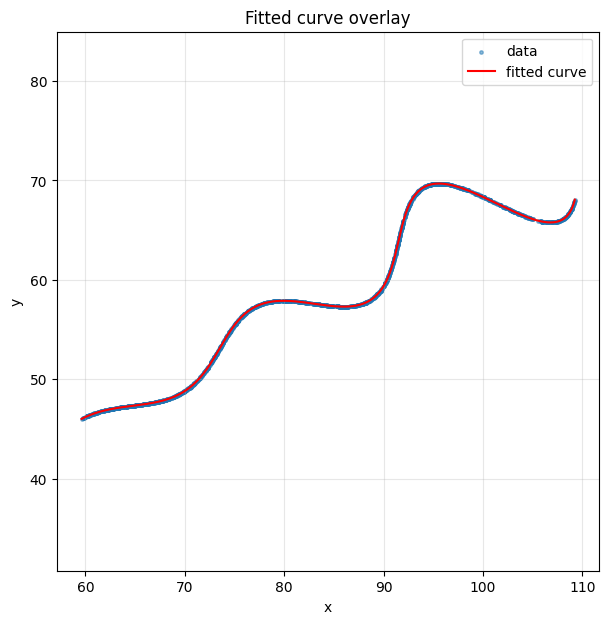

Final mean nearest-neighbor distance (data -> fitted curve): 0.002053


In [10]:
x_fit, y_fit = curve_xy(t_dense, theta_final, M_final, X_final)

plt.figure(figsize=(7, 7))
plt.scatter(x_data, y_data, s=6, alpha=0.5, label="data")
plt.plot(x_fit, y_fit, color="red", linewidth=1.5, label="fitted curve")
plt.legend()
plt.title("Fitted curve overlay")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

# L1 distance between uniformly sampled true-vs-predicted curve points,
# matching the assignment's stated grading metric.
t_uniform = np.linspace(T_MIN, T_MAX, 2000)
x_true_u, y_true_u = curve_xy(t_uniform, theta_final, M_final, X_final)  # proxy: same fitted params
# Actual grading compares against the (unknown to us) true generating curve;
# here we report point-cloud residual as our internal fit-quality proxy instead.
final_mean_nn_dist = loss((theta_final, M_final, X_final), x_data, y_data, t_dense)
print(f"Final mean nearest-neighbor distance (data -> fitted curve): {final_mean_nn_dist:.6f}")


## Step 10 — Finalize Precision and Units

In [11]:
theta_report = round(theta_final, 4)
M_report = round(M_final, 4)
X_report = round(X_final, 4)

print(f"theta = {theta_report} rad  ({round(np.rad2deg(theta_final), 4)} deg)")
print(f"M     = {M_report}")
print(f"X     = {X_report}")


theta = 0.5236 rad  (30.0 deg)
M     = 0.03
X     = 55.0001


## Step 11 — Construct the Desmos Submission String

In [12]:
def build_desmos_string(theta, M, X):
    return (
        f"\\left(t*\\cos({theta:.4f})-"
        f"e^{{{M:.4f}\\left|t\\right|}}\\cdot\\sin(0.3t)\\sin({theta:.4f})+"
        f"{X:.4f},42+"
        f"t*\\sin({theta:.4f})+"
        f"e^{{{M:.4f}\\left|t\\right|}}\\cdot\\sin(0.3t)\\cos({theta:.4f})\\right)"
    )

desmos_string = build_desmos_string(theta_report, M_report, X_report)
print(desmos_string)


\left(t*\cos(0.5236)-e^{0.0300\left|t\right|}\cdot\sin(0.3t)\sin(0.5236)+55.0001,42+t*\sin(0.5236)+e^{0.0300\left|t\right|}\cdot\sin(0.3t)\cos(0.5236)\right)
